In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

import warnings
warnings.filterwarnings("ignore")
np.seterr(all="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

### Toth Model

In [26]:
def toth_model(x, pressure, T):            
    qs_val = x[0] * np.exp(x[1] * (1.0 - (T / T0)))
    b_val  = x[2] * np.exp((-dH / (R * T0)) * ((T0 / T) - 1.0))
    t_val  = x[3] + x[4] * (1.0 - (T0 / T))

    q_star = (qs_val * b_val * pressure)/((1 + (b_val * pressure)**t_val)**(1 / t_val))

    return q_star

def residuals_toth(x, pressure, T, y_Toth):            
    q_pred = toth_model(x, pressure, T)
    return q_pred - y_Toth

In [27]:
# Jung and Lee dry CO2 data
R = 8.314

T0 = 313
dH = -53970

JLdry_co2_pts = pd.read_csv('JLdry_co2pts.csv')

pressures = JLdry_co2_pts['pCO2 (bar)'].values * 100 # to put in kPa
Temps = JLdry_co2_pts['Temp (K)'].values
y_values = JLdry_co2_pts['CO2 Adsorption (mmol/g)'].values

In [28]:
num_starts = 500
best_res = np.inf
best_params = None

# Define physically realistic initialization bounds
# [qs0, chi, b0, t0, alpha]
init_lower = [0.001, -5.0,   0.001, 0.001, -5.0]
init_upper = [20.0,   5.0, 200.0,   1.0,    5.0]


for i in range(num_starts):
    # Pick random starting point
    x0_random = np.random.uniform(low=init_lower, high=init_upper)
        
    try:
    # Run unbounded optimization
        results = least_squares(
            residuals_toth, 
            x0_random, 
            args=(pressures, Temps, y_values),
            method='lm' 
        )
        
        if results.success:
            ssr = sum(results.fun**2)
            
            if ssr < best_res:
                best_res = ssr
                best_params = results.x
                    
    except Exception as e:
         pass


# Print Best Results
print(f"Global Best SSR: {best_res:.6f}")
print(f"qs0 (Sat Capacity) : {best_params[0]:.4f} mmol/g")
print(f"chi (Temp dep qs)  : {best_params[1]:.4f}")
print(f"b0 (Affinity)      : {best_params[2]:.4f} kPa-1")
print(f"t0 (Heterogeneity) : {best_params[3]:.4f}")
print(f"alpha (Temp dep t) : {best_params[4]:.4f}")

Global Best SSR: 0.152358
qs0 (Sat Capacity) : 3.3284 mmol/g
chi (Temp dep qs)  : -3.0860
b0 (Affinity)      : 76.0451 kPa-1
t0 (Heterogeneity) : 0.3436
alpha (Temp dep t) : -1.2471


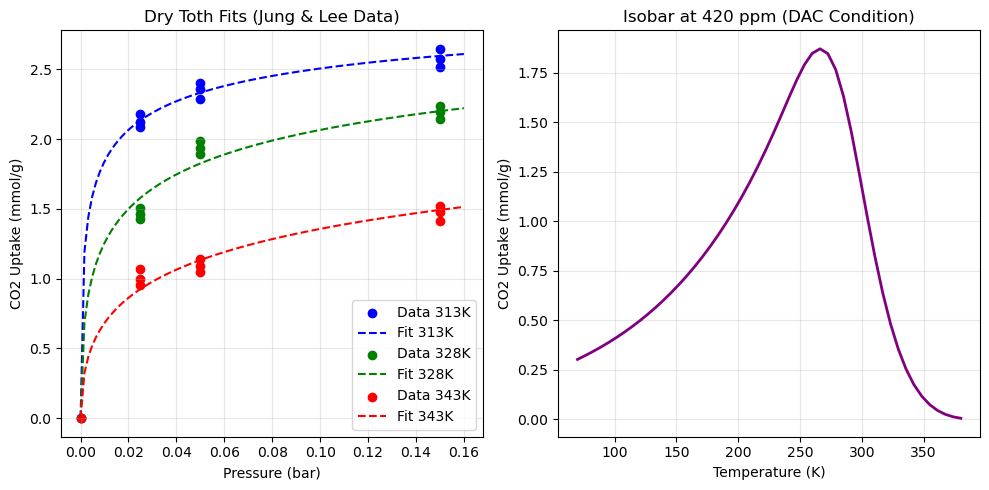

In [29]:
# Plotting
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
colors = {313: 'blue', 328: 'green', 343: 'red'}
p_bar = np.linspace(0, 0.16, 100)
p_kPa = p_bar * 100

# Plot 1: Isotherms
for T_val in [313, 328, 343]:
    subset = JLdry_co2_pts[JLdry_co2_pts['Temp (K)'] == T_val]
    axs[0].scatter(subset['pCO2 (bar)'], subset['CO2 Adsorption (mmol/g)'], 
                   color=colors[T_val], label=f'Data {T_val}K')
    
    q_pred_curve = toth_model(best_params, p_kPa, T_val)
    axs[0].plot(p_bar, q_pred_curve, color=colors[T_val], linestyle='--', label=f'Fit {T_val}K')

axs[0].set_xlabel('Pressure (bar)')
axs[0].set_ylabel('CO2 Uptake (mmol/g)')
axs[0].set_title('Dry Toth Fits (Jung & Lee Data)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Isobar at 420 ppm (0.042 kPa)
T_range = np.linspace(70, 380, 50)
q_dac = toth_model(best_params, pressure=0.042, T=T_range)

axs[1].plot(T_range, q_dac, color='purple', linewidth=2)
axs[1].set_xlabel('Temperature (K)')
axs[1].set_ylabel('CO2 Uptake (mmol/g)')
axs[1].set_title('Isobar at 420 ppm (DAC Condition)')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
num_starts = 500
best_res = np.inf
best_params = None

# Realistic initialization bounds
# [qs0, chi, b0, t0, alpha]
init_lower = [1, -5, 0.001, 0.001,   -5.0]
init_upper = [5,  5,   200,   1.0,    5.0]

# Solver bounds
solver_lower = [1, -5, 1e-8,  1e-5, -5]
solver_upper = [5,  5,  200,   1.0,  5]


for i in range(num_starts):
    x0_random = np.random.uniform(low=init_lower, high=init_upper)
    
    try:
        results = least_squares(
            residuals_toth, 
            x0_random, 
            args=(pressures, Temps, y_values),
            bounds=(solver_lower, solver_upper),
            method='trf' 
        )
        
        if results.success:
            ssr = sum(results.fun**2)
            
            if ssr < best_res:
                best_res = ssr
                best_params = results.x
                
    except Exception as e:
        pass


# Print Best Results
print(f"Global Best SSR: {best_res:.6f}")
print(f"qs0 (Sat Capacity) : {best_params[0]:.4f} mmol/g")
print(f"chi (Temp dep qs)  : {best_params[1]:.4f}")
print(f"b0 (Affinity)      : {best_params[2]:.4f} kPa-1")
print(f"t0 (Heterogeneity) : {best_params[3]:.4f}")
print(f"alpha (Temp dep t) : {best_params[4]:.4f}")

Global Best SSR: 0.152358
qs0 (Sat Capacity) : 3.3284 mmol/g
chi (Temp dep qs)  : -3.0860
b0 (Affinity)      : 76.0451 kPa-1
t0 (Heterogeneity) : 0.3436
alpha (Temp dep t) : -1.2471


In [31]:
# Wang and Chen dry CO2 data
R = 8.314

T0 = 323.15 # K
dH = -119600 # Joules (∆H)

WC_co2 = pd.read_csv('WangChen_co2.csv')

pressures = WC_co2['pCO2 (kPa)'].values # kPa
Temps = WC_co2['Temp (K)'].values
y_values = WC_co2['CO2 Adsorption (mmol/g)'].values

In [32]:
num_starts = 500
best_res = np.inf
best_params = None

# Define physically realistic initialization bounds
# [qs0, chi, b0, t0, alpha]
init_lower = [0.001, -5.0,   0.001, 0.001, -5.0]
init_upper = [20.0,   5.0, 200.0,   1.0,    5.0]


for i in range(num_starts):
    # Pick random starting point
    x0_random = np.random.uniform(low=init_lower, high=init_upper)
        
    try:
    # Run unbounded optimization
        results = least_squares(
            residuals_toth, 
            x0_random, 
            args=(pressures, Temps, y_values),
            method='lm' 
        )
        
        if results.success:
            ssr = sum(results.fun**2)
            
            if ssr < best_res:
                best_res = ssr
                best_params = results.x
                    
    except Exception as e:
         pass


# Print Best Results
print(f"Global Best SSR: {best_res:.6f}")
print(f"qs0 (Sat Capacity) : {best_params[0]:.4f} mmol/g")
print(f"chi (Temp dep qs)  : {best_params[1]:.4f}")
print(f"b0 (Affinity)      : {best_params[2]:.4f} kPa-1")
print(f"t0 (Heterogeneity) : {best_params[3]:.4f}")
print(f"alpha (Temp dep t) : {best_params[4]:.4f}")

Global Best SSR: 0.014880
qs0 (Sat Capacity) : 0.8934 mmol/g
chi (Temp dep qs)  : -4.3209
b0 (Affinity)      : 57.9359 kPa-1
t0 (Heterogeneity) : 0.5820
alpha (Temp dep t) : 1.5951


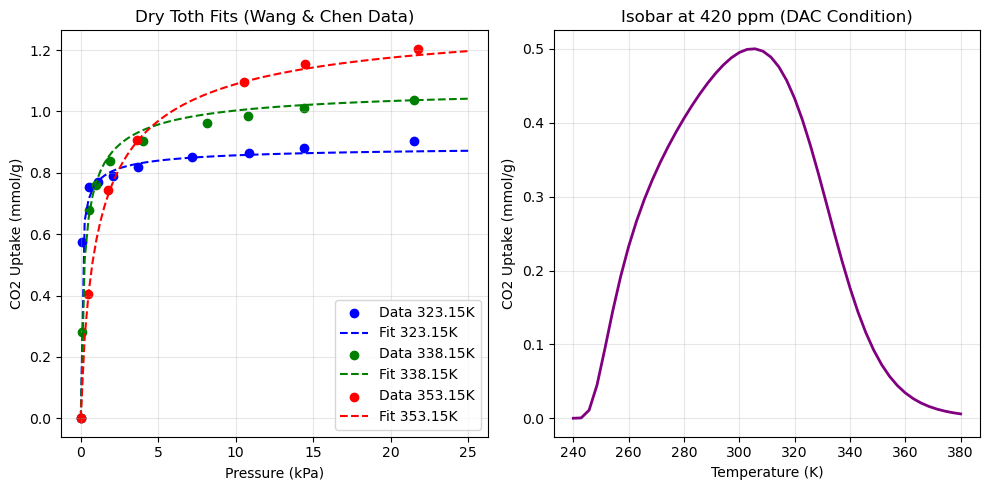

In [41]:
# Plotting
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
colors = {323.15: 'blue', 338.15: 'green', 353.15: 'red'}
p_kPa = np.linspace(0, 25, 100)

# Plot 1: Isotherms
for T_val in [323.15, 338.15, 353.15]:
    subset = WC_co2[WC_co2['Temp (K)'] == T_val]
    axs[0].scatter(subset['pCO2 (kPa)'], subset['CO2 Adsorption (mmol/g)'], 
                   color=colors[T_val], label=f'Data {T_val}K')
    
    q_pred_curve = toth_model(best_params, p_kPa, T_val)
    axs[0].plot(p_kPa, q_pred_curve, color=colors[T_val], linestyle='--', label=f'Fit {T_val}K')

axs[0].set_xlabel('Pressure (kPa)')
axs[0].set_ylabel('CO2 Uptake (mmol/g)')
axs[0].set_title('Dry Toth Fits (Wang & Chen Data)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Isobar at 420 ppm (0.042 kPa)
T_range = np.linspace(240, 380, 50)
q_dac = toth_model(best_params, pressure=0.042, T=T_range)

axs[1].plot(T_range, q_dac, color='purple', linewidth=2)
axs[1].set_xlabel('Temperature (K)')
axs[1].set_ylabel('CO2 Uptake (mmol/g)')
axs[1].set_title('Isobar at 420 ppm (DAC Condition)')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### GAB Fitting

In [81]:
# Calculate RH Using Clausius-Clapeyron
def get_RH(Temp,pH2O_kPa):
    Ps_Pa = 611.3 * np.exp(5417.1 * (1 / 273.15 - 1 / Temp))
    RH = (pH2O_kPa*1000) / Ps_Pa 
    return RH

def GAB_model(x, RH, T):
    C = x[1] * np.exp(-dH_C / (R * T))
    K = x[2] * np.exp(-dH_K / (R * T))
    
    numerator = x[0] * C * K * RH
    denom = (1 - K * RH) * (1 + (C - 1) * K * RH)
    
    return numerator / denom

def residuals_GAB(x, RH, T, y_GAB):            
    q_h2o = GAB_model(x, RH, T)
    return q_h2o - y_GAB

def GAB_model_fit_dH(x, RH, T):
    q_m  = x[0]
    C0   = x[1]
    K0   = x[2]
    dH_C = x[3]
    dH_K = x[4]

    C = C0 * np.exp(-dH_C / (R * T))
    K = K0 * np.exp(-dH_K / (R * T))
    
    numerator = q_m * C * K * RH
    denom = (1 - K * RH) * (1 + (C - 1) * K * RH)
    
    return numerator / denom

def residuals_GAB_fit_dH(x, RH, T, y_GAB):            
    q_h2o = GAB_model_fit_dH(x, RH, T)
    return q_h2o - y_GAB

def GAB_model_fit_dH_C(x, RH, T):
    q_m  = x[0]
    C0   = x[1]
    K0   = x[2]
    dH_C = x[3]

    C = C0 * np.exp(-dH_C / (R * T))
    K = K0 * np.exp(-dH_K / (R * T))
    
    numerator = q_m * C * K * RH
    denom = (1 - K * RH) * (1 + (C - 1) * K * RH)
    
    return numerator / denom

def residuals_GAB_fit_dH_C(x, RH, T, y_GAB):            
    q_h2o = GAB_model_fit_dH_C(x, RH, T)
    return q_h2o - y_GAB

In [89]:
# Jung and Lee H2O data
gab_h2o = pd.read_csv('JL_h2o_pts.csv')
T_values = [313, 328, 343]

pressures_h2o = gab_h2o['pH2O (bar)'].values * 100
Temps_h2o = gab_h2o['Temp (K)'].values
y_h2o = gab_h2o['Adsorption (mmol/g)'].values
RH_array = get_RH(Temps_h2o, pressures_h2o)

In [141]:
num_starts = 500
best_res_roam = np.inf
best_params_roam = None

# Fit both ∆H_C and ∆H_K
# [qm, C0, kG0, dH_C, dH_K]
lower_roam = [1.0, 1e-16, 1e-4, -90000, -30000]
upper_roam = [10.0, 1e-4, 1e2, -30000, 0]

for i in range(num_starts):
    x0 = np.random.uniform(low=lower_roam, high=upper_roam)
    try:
        res = least_squares(residuals_GAB_fit_dH, x0, args=(RH_array, Temps_h2o, y_h2o),
                            bounds=(lower_roam, upper_roam), method='trf')
        if res.success and sum(res.fun**2) < best_res_roam:
            best_res_roam, best_params_roam = sum(res.fun**2), res.x
    except: pass

# Fit just ∆H_C
dH_K = 0 # Fixed constant

best_res_fix = np.inf
best_params_fix = None

# [qm, C0, kG0, dH_C]
lower_fix = [1.0, 1e-16, 1e-4, -90000]
upper_fix = [10.0, 1e-4, 1e2, -30000]

for i in range(num_starts):
    x0 = np.random.uniform(low=lower_fix, high=upper_fix)
    try:
        res = least_squares(residuals_GAB_fit_dH_C, x0, args=(RH_array, Temps_h2o, y_h2o),
                            bounds=(lower_fix, upper_fix), method='trf')
        if res.success and sum(res.fun**2) < best_res_fix:
            best_res_fix, best_params_fix = sum(res.fun**2), res.x
    except: pass

# Print results of both
print("\n Scenario 1 Results")
print(f"SSR: {best_res_roam:.4f}")
print(f"qm: {best_params_roam[0]:.4f}")
print(f"C0: {best_params_roam[1]:.4e}")
print(f"kG0: {best_params_roam[2]:.4e}")
print(f"dH_C: {best_params_roam[3]:.0f}")
print(f"dH_K: {best_params_roam[4]:.0f}")

for T in [313, 328, 343]:
    C_r = best_params_roam[1] * np.exp(-best_params_roam[3] / (R * T))
    K_r = best_params_roam[2] * np.exp(-best_params_roam[4] / (R * T))
    print(f"T = {T} K  ->  C = {C_r:.4f}  |  K = {K_r:.4f}")

print("\n Scenario 2 Results")
print(f"SSR: {best_res_fix:.4f}")
print(f"qm: {best_params_fix[0]:.4f}")
print(f"C0: {best_params_fix[1]:.4e}")
print(f"kG0: {best_params_fix[2]:.4e}")
print(f"dH_C: {best_params_fix[3]:.0f}")

for T in [313, 328, 343]:
    C_f = best_params_fix[1] * np.exp(-best_params_fix[3] / (R * T))
    K_f = best_params_fix[2] * np.exp(-0 / (R * T))
    print(f"T = {T} K  ->  C = {C_f:.4f}  |  K = {K_f:.4f}")



 Scenario 1 Results
SSR: 0.0821
qm: 4.9264
C0: 6.6125e-06
kG0: 4.2034e-03
dH_C: -44132
dH_K: -1577
T = 313 K  ->  C = 153.2796  |  K = 0.0077
T = 328 K  ->  C = 70.5773  |  K = 0.0075
T = 343 K  ->  C = 34.7780  |  K = 0.0073

 Scenario 2 Results
SSR: 0.0531
qm: 3.8912
C0: 2.3436e-06
kG0: 1.0073e-04
dH_C: -59207
T = 313 K  ->  C = 17818.5260  |  K = 0.0001
T = 328 K  ->  C = 6295.0184  |  K = 0.0001
T = 343 K  ->  C = 2435.8179  |  K = 0.0001


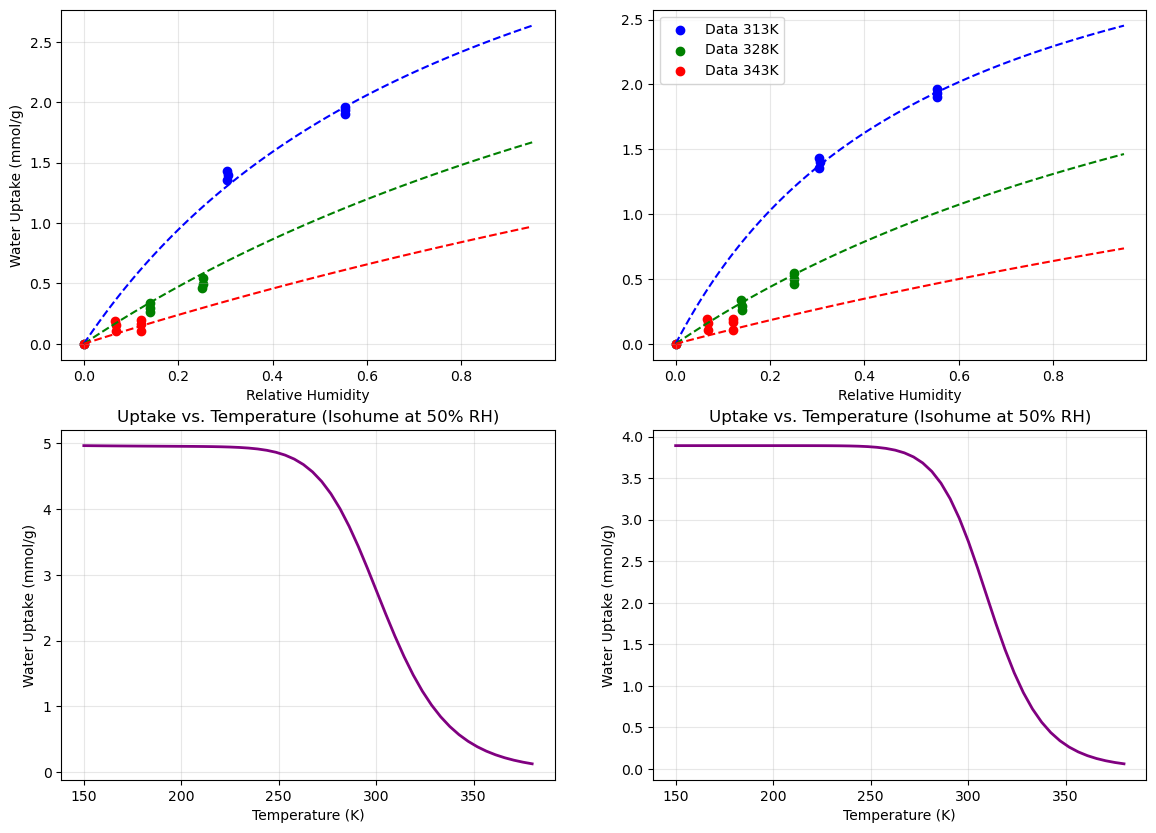

In [142]:
# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()
colors = {313: 'blue', 328: 'green', 343: 'red'}
RH_plot = np.linspace(0, 0.95, 100)

for T_val in T_values:
    subset = gab_h2o[gab_h2o['Temp (K)'] == T_val]
    RH_sub = get_RH(T_val, subset['pH2O (bar)'].values * 100)
    
    # Plot Data on both
    axs[0].scatter(RH_sub, subset['Adsorption (mmol/g)'], color=colors[T_val], label=f'Data {T_val}K')
    axs[1].scatter(RH_sub, subset['Adsorption (mmol/g)'], color=colors[T_val], label=f'Data {T_val}K')
    
    T_plot = np.full_like(RH_plot, T_val)
    
    # First curve
    q_pred_A = GAB_model_fit_dH(best_params_roam, RH_plot, T_plot)
    axs[0].plot(RH_plot, q_pred_A, '--', color=colors[T_val])
    
    # Second curve
    q_pred_B = GAB_model_fit_dH_C(best_params_fix, RH_plot, T_plot)
    axs[1].plot(RH_plot, q_pred_B, '--', color=colors[T_val])

axs[0].set_xlabel('Relative Humidity')
axs[0].set_ylabel('Water Uptake (mmol/g)')
axs[0].grid(True, alpha=0.3)

axs[1].set_xlabel('Relative Humidity')
axs[1].grid(True, alpha=0.3)
axs[1].legend()

# Plot 2: Uptake vs Temperature at 50% RH
T_range = np.linspace(150, 380, 50)
RH_constant = np.full_like(T_range, 0.50)
q_temp_decay = GAB_model_fit_dH(best_params_roam, RH_constant, T_range)

axs[2].plot(T_range, q_temp_decay, color='purple', linewidth=2)
axs[2].set_xlabel('Temperature (K)')
axs[2].set_ylabel('Water Uptake (mmol/g)')
axs[2].set_title('Uptake vs. Temperature (Isohume at 50% RH)')
axs[2].grid(True, alpha=0.3)

q_temp_decay1 = GAB_model_fit_dH_C(best_params_fix, RH_constant, T_range)

axs[3].plot(T_range, q_temp_decay1, color='purple', linewidth=2)
axs[3].set_xlabel('Temperature (K)')
axs[3].set_ylabel('Water Uptake (mmol/g)')
axs[3].set_title('Uptake vs. Temperature (Isohume at 50% RH)')
axs[3].grid(True, alpha=0.3)

plt.show()

In [44]:
# Wang and Chen H2O data
gab_h2o = pd.read_csv('WangChen_h2o.csv')

dH_L = 43600  
dH_C = -84848 + dH_L # -41248 J/mol
dH_K = -44696 + dH_L # -1096 J/mol

T_values = [323.15, 338.15, 353.15]

pressures_h2o = gab_h2o['pH2O (kPa)'].values
Temps_h2o = gab_h2o['Temp (K)'].values
y_h2o = gab_h2o['Adsorption (mmol/g)'].values
RH_array = get_RH(Temps_h2o, pressures_h2o)

In [47]:
num_starts = 500
best_res = np.inf
best_params = None

# Define physically realistic initialization bounds
# [qm, C0, kG0]
init_lower = [0.5,  1e-7, 0.01]
init_upper = [10.0, 1e-2, 0.5]

# Bounds for the solver
solver_lower = [0.001, 1e-10, 1e-6]
solver_upper = [30.0,  1.0,   0.99]

for i in range(num_starts):
    x0_random = np.random.uniform(low=init_lower, high=init_upper)
    
    try:
        res = least_squares(
            residuals_GAB, 
            x0_random, 
            args=(RH_array, Temps_h2o, y_h2o),
            bounds=(solver_lower, solver_upper),
            method='trf'
        )
        
        if res.success:
            ssr = sum(res.fun**2)
            if ssr < best_res:
                best_res = ssr
                best_params = res.x
                
    except Exception as e:
        pass


# Print Results
print(f"Global Best SSR: {best_res:.6f}")
print(f"qm (Monolayer Capacity): {best_params[0]:.4f} mmol/g")
print(f"C0 (Monolayer Pre-exp) : {best_params[1]:.4e}")
print(f"kG0(Multilayer Pre-exp): {best_params[2]:.4e}\n")

for T in T_values:
    C_T = best_params[1] * np.exp(-dH_C / (R * T))
    K_T = best_params[2] * np.exp(-dH_K / (R * T))
    print(f"T = {T} K  ->  C = {C_T:.4f}  |  K = {K_T:.4f}")

Global Best SSR: 3.052470
qm (Monolayer Capacity): 3.0555 mmol/g
C0 (Monolayer Pre-exp) : 4.2090e-06
kG0(Multilayer Pre-exp): 6.0859e-01

T = 323.15 K  ->  C = 19.5810  |  K = 0.9152
T = 338.15 K  ->  C = 9.9098  |  K = 0.8987
T = 353.15 K  ->  C = 5.3140  |  K = 0.8840


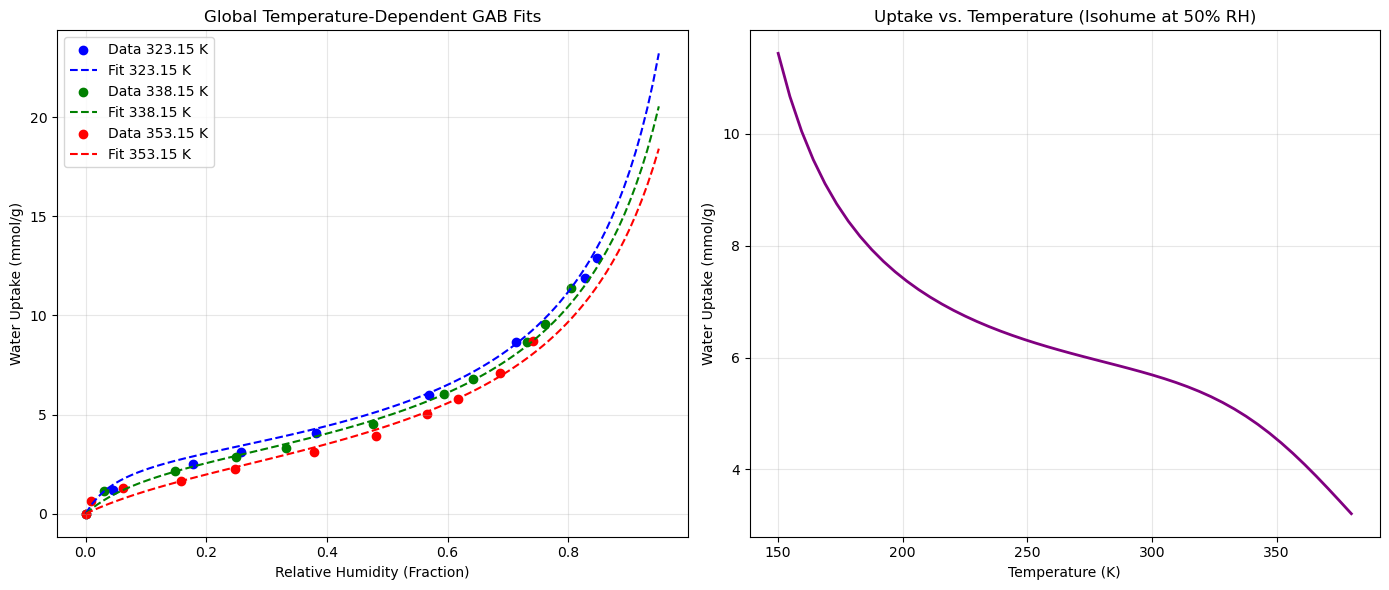

In [59]:
# Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
colors = {323.15: 'blue', 338.15: 'green', 353.15: 'red'}

# Plot 1: Isotherms
RH_plot = np.linspace(0, 0.95, 100)

for T_val in T_values:
    subset = gab_h2o[gab_h2o['Temp (K)'] == T_val]
    RH_sub = get_RH(T_val, subset['pH2O (kPa)'].values)
    axs[0].scatter(RH_sub, subset['Adsorption (mmol/g)'], color=colors[T_val], label=f'Data {T_val} K')
    
    T_plot = np.full_like(RH_plot, T_val)
    q_pred = GAB_model(best_params, RH_plot, T_plot)
    axs[0].plot(RH_plot, q_pred, '--', color=colors[T_val], label=f'Fit {T_val} K')

axs[0].set_xlabel('Relative Humidity (Fraction)')
axs[0].set_ylabel('Water Uptake (mmol/g)')
axs[0].set_title('Global Temperature-Dependent GAB Fits')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Uptake vs Temperature at 50% RH
T_range = np.linspace(150, 380, 50)
RH_constant = np.full_like(T_range, 0.50)
q_temp_decay = GAB_model(best_params, RH_constant, T_range)

axs[1].plot(T_range, q_temp_decay, color='purple', linewidth=2)
axs[1].set_xlabel('Temperature (K)')
axs[1].set_ylabel('Water Uptake (mmol/g)')
axs[1].set_title('Uptake vs. Temperature (Isohume at 50% RH)')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### WADST Fitting

In [119]:
def WADST_fit(x, P_co2, q_h2o, T):
    # Evaluate dry parameters
    qs_d = qs0_d * np.exp(chi_d * (1.0 - T / T0))
    b_d  = b0_d * np.exp((-dH_d / (R * T0)) * ((T0 / T) - 1.0))
    t_d  = t0_d + alpha_d * (1.0 - (T0 / T))

    # Evaluate wet parameters
    # x = [qs0_w, chi_w, b0_w, t0_w, alpha_w, A]
    qs_w = x[0] * np.exp(x[1] * (1.0 - T / T0))
    b_w  = x[2] * np.exp((-dH_w / (R * T0)) * ((T0 / T) - 1.0))
    t_w  = x[3] + x[4] * (1.0 - (T0 / T))

    # Dont model water below 1e-9
    q_safe = np.maximum(q_h2o, 1e-9)
    weight = np.exp(-x[5] / q_safe)

    # Calculate terms
    dry_term = (qs_d * b_d * P_co2) / ((1.0 + (b_d * P_co2)**t_d)**(1.0/t_d))
    wet_term = (qs_w * b_w * P_co2) / ((1.0 + (b_w * P_co2)**t_w)**(1.0/t_w))

    q_total = (1.0 - weight) * dry_term + weight * wet_term
    return q_total

def residuals_WADST(x, P_co2, q_h2o, T, q_exp):
    q_model = WADST_fit(x, P_co2, q_h2o, T)
    return q_model - q_exp

def gab_isotherm(RH, T):
    C = C0 * np.exp(-dH_C / (R * T))
    K = kG0 * np.exp(-dH_K / (R * T))
    
    num = qm_gab * C * K * RH
    den = (1 - K * RH) * (1 - K * RH + C * K * RH)
    return num / den    

In [149]:
# Jung and Lee WADST 
JL_WADST = pd.read_csv('JL_co2h2o_pts.csv')

P_h2o_JL = JL_WADST['pH2O (bar)'].values * 100  # kPa
P_co2_JL = JL_WADST['pCO2 (bar)'].values * 100  # kPa
T_JL = JL_WADST['Temp (K)'].values
y_co2_JL = JL_WADST['CO2 Adsorption (mmol/g)'].values

# Dry Toth Parameters
qs0_d = 3.3284
chi_d = -3.0860
b0_d = 76.0440
dH_d = -53970 
t0_d = 0.3436
alpha_d = -1.2472

# Wet CO2 Enthalpy
dH_w = -67670

# Water GAB Parameters
qm_gab = 3.8415
C0 = 1.7852e-06
kG0 = 1.0000e-04
dH_C = -54793
dH_K = -5202

RH_JL = get_RH(T_JL, P_h2o_JL)
q_h2o_JL = gab_isotherm(RH_JL, T_JL)

In [160]:
num_starts = 500
best_res = np.inf
best_params = None

# Variables: [qs0_w, chi_w, b0_w, t0_w, alpha_w, A]
init_lower = [0.1,  -10.0, 0,  0.001, -10.0, 0.5]
init_upper = [15.0,  10.0, 500.0, 1.0,    10.0, 5.0]

# Bounds for the solver 
solver_lower = [0.001, -100.0, 0,    1e-5, -100.0, 0.5]
solver_upper = [100.0,  100.0, 10000.0, 10.0,  100.0, 20.0]

for i in range(num_starts):
    x0_random = np.random.uniform(low=init_lower, high=init_upper)
    try:
        results = least_squares(
            residuals_WADST, 
            x0_random, 
            args=(P_co2_JL, q_h2o_JL, T_JL, y_co2_JL),
            bounds=(solver_lower, solver_upper),
            method='trf'
        )
        if results.success and sum(results.fun**2) < best_res:
            best_res = sum(results.fun**2)
            best_params = results.x
    except:
        pass

# Print Output
print(f"Global Best SSR: {best_res:.4f}")
print(f"qs0_w  : {best_params[0]:.4f} mmol/g")
print(f"chi_w  : {best_params[1]:.4f}")
print(f"b0_w   : {best_params[2]:.4f} kPa^-1")
print(f"t0_w   : {best_params[3]:.4f}")
print(f"alpha_w: {best_params[4]:.4f}")
print(f"A (wt) : {best_params[5]:.4f} mmol/g")

Global Best SSR: 4.9673
qs0_w  : 84.3499 mmol/g
chi_w  : -76.5122
b0_w   : 0.0021 kPa^-1
t0_w   : 9.8352
alpha_w: 13.7332
A (wt) : 0.5000 mmol/g


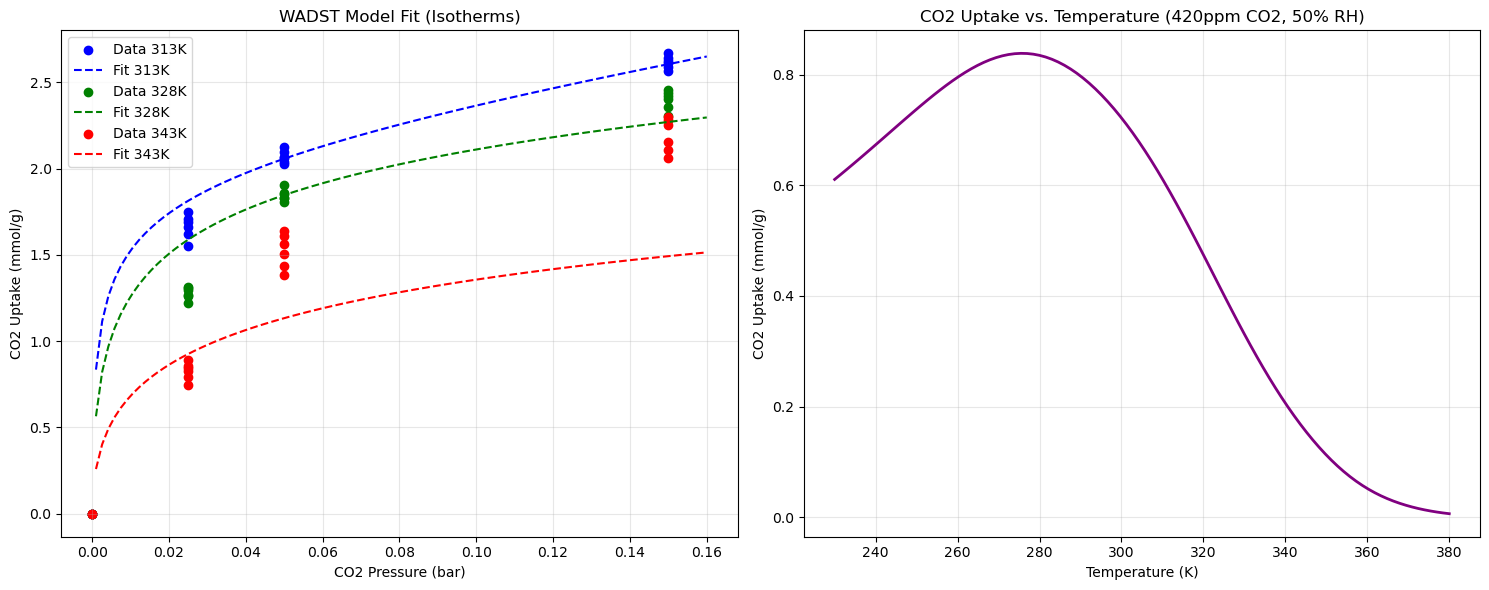

In [161]:
# Plotting
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
colors = {313: 'blue', 328: 'green', 343: 'red'}

p_bar = np.linspace(0.001, 0.16, 100)
p_kPa = p_bar * 100

# Plot 1: Isotherm
unique_temps = np.unique(T_JL)
for T_val in unique_temps:
    subset = JL_WADST[JL_WADST['Temp (K)'] == T_val]
    if len(subset) == 0: continue
        
    c_key = int(T_val)
    lbl_color = colors.get(c_key, 'black')
    
    # Scatter Data
    axs[0].scatter(subset['pCO2 (bar)'], subset['CO2 Adsorption (mmol/g)'], 
                   color=lbl_color, label=f'Data {T_val}K')
    
    # Average the experimental water pressure for the modeled curve
    P_h2o_subset = subset['pH2O (bar)'].values * 100
    RH_subset = get_RH(T_val, P_h2o_subset)
    q_h2o_avg = np.mean(gab_isotherm(RH_subset, T_val))
    
    # Predict Curve
    q_pred_curve = WADST_fit(best_params, p_kPa, q_h2o_avg, T_val)
    axs[0].plot(p_bar, q_pred_curve, color=lbl_color, linestyle='--', label=f'Fit {T_val}K')

axs[0].set_xlabel('CO2 Pressure (bar)')
axs[0].set_ylabel('CO2 Uptake (mmol/g)')
axs[0].set_title('WADST Model Fit (Isotherms)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Uptake vs Temp
# Modeling DAC conditions: CO2 at 420 ppm (0.042 kPa) and ~50% Relative Humidity
T_range = np.linspace(230, 380, 100)
P_co2_dac = np.full_like(T_range, 0.042)  # Fixed at 0.042 kPa CO2
RH_dac = np.full_like(T_range, 0.50)      # Fixed at 50% RH

q_h2o_dac = gab_isotherm(RH_dac, T_range)
q_dac_curve = WADST_fit(best_params, P_co2_dac, q_h2o_dac, T_range)

axs[1].plot(T_range, q_dac_curve, color='purple', linewidth=2)
axs[1].set_xlabel('Temperature (K)')
axs[1].set_ylabel('CO2 Uptake (mmol/g)')
axs[1].set_title('CO2 Uptake vs. Temperature (420ppm CO2, 50% RH)')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Success: True
Residual: 0.4934827816494252
qs0 (Sat Capacity) : 3.7059 mmol/g
chi (Temp dep qs)  : -1.8427
b0 (Affinity)      : 1.8369 kPa-1
t0 (Heterogeneity) : 0.4911
alpha (Temp dep t) : 1.3259


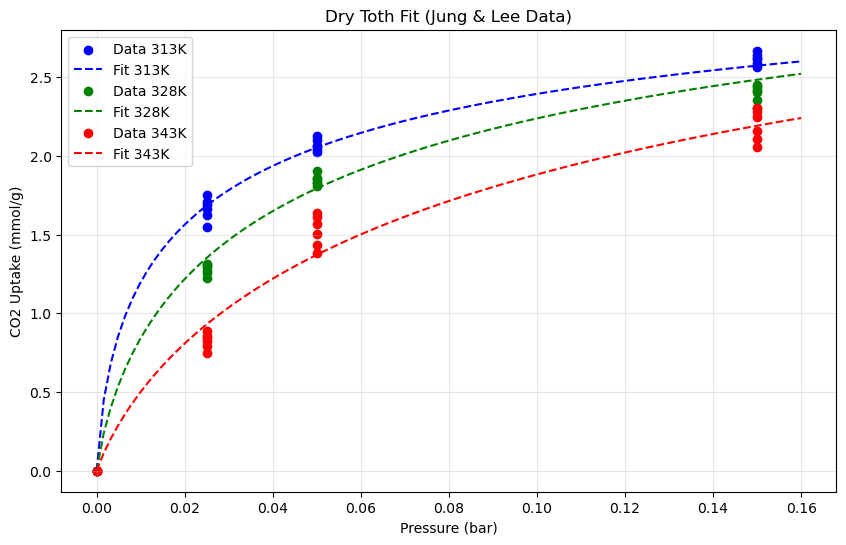

In [153]:
# Try with raw data pts file of Jung & Lee
JLdry_co2_pts = pd.read_csv('JL_co2h2o_pts.csv')

T0 = 313 #K
dH = -67670 # Joules (∆H)

pressures = JLdry_co2_pts['pCO2 (bar)'].values * 100 # to put in kPa
Temps = JLdry_co2_pts['Temp (K)'].values
y_values = JLdry_co2_pts['CO2 Adsorption (mmol/g)'].values

x0 = [2.72, 0.01, 36.11, 0.25, 0.2]

results = least_squares(residuals_toth, x0, args=(pressures, Temps, y_values),
            bounds=([-np.inf, -np.inf, -np.inf, -np.inf, -np.inf,], [np.inf, np.inf, np.inf, np.inf, np.inf]))
            #bounds=([0, -np.inf, 0, 0, -np.inf,], [np.inf, np.inf, np.inf, 1, np.inf]))
            #bounds=([1, 0, 0, 0.001, 0.001,], [160, 5, np.inf, 1, 3]))
            #bounds=([1, 0.01, 0, 0.001, -10,], [160, 5, 100, 1, 10]))
            #bounds=([1, 0.01, 10, 0.001, 0.001,], [160, 5, 100, 1, 3]))

print("Success:", results.success)
print("Residual:", sum(results.fun**2))

params_fitted = results.x
print(f"qs0 (Sat Capacity) : {params_fitted[0]:.4f} mmol/g")
print(f"chi (Temp dep qs)  : {params_fitted[1]:.4f}")
print(f"b0 (Affinity)      : {params_fitted[2]:.4f} kPa-1")
print(f"t0 (Heterogeneity) : {params_fitted[3]:.4f}")
print(f"alpha (Temp dep t) : {params_fitted[4]:.4f}")

plt.figure(figsize=(10, 6))
colors = {313: 'blue', 328: 'green', 343: 'red'}

p_bar = np.linspace(0, 0.16, 100)
p_kPa = p_bar * 100

for T_val in [313, 328, 343]:
    # Raw data points
    subset = JLdry_co2_pts[JLdry_co2_pts['Temp (K)'] == T_val]
    plt.scatter(subset['pCO2 (bar)'], subset['CO2 Adsorption (mmol/g)'], 
                color=colors[T_val], label=f'Data {T_val}K')
    
    # Fitted curve
    q_pred_curve = toth_model(params_fitted, p_kPa, T_val)
    plt.plot(p_bar, q_pred_curve, color=colors[T_val], linestyle='--', label=f'Fit {T_val}K')

plt.xlabel('Pressure (bar)')
plt.ylabel('CO2 Uptake (mmol/g)')
plt.title('Dry Toth Fit (Jung & Lee Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

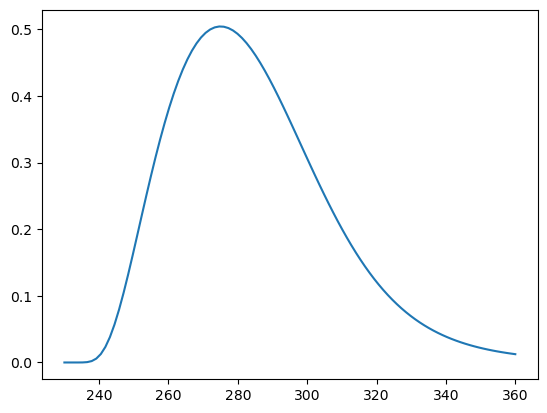

In [159]:
# define Toth model functions
def get_qs(T):
    return qs0 * np.exp(chi * (1 - T / T0)) # eq 9

def get_b(T):
    exponent = (-dH / (R * T0)) * ((T0 / T) - 1)
    return b0 * np.exp(exponent) # eq 10

def get_t(T):
    return t0 + alpha * (1 - (T0 / T)) # eq 11

def toth_isotherm(pressure, T):
    qs_val = get_qs(T)
    b_val = get_b(T)
    t_val = get_t(T)
    
    numerator = qs_val * b_val * pressure
    denominator = (1 + (b_val * pressure)**t_val)**(1 / t_val)
    
    return numerator / denominator # eq 8 (mol/kg) 


T = np.linspace(230,360,100)
T0 = 313 # K
p_Co2 = 420/1000000 * (101.325) # ppm to kPa

qs0 = 3.7059
chi = -1.8427
b0 = 1.8369
t0 = 0.4911
alpha = 1.3259

test = toth_isotherm(p_Co2, T)

plt.plot(T,test)